for tissue annotation we can use a tissue predictor, such as ml marker

In [1]:
import pandas as pd
import numpy as np
import re
from mlmarker import MLMarker

# Load data
nsaf = pd.read_parquet(r"C:\Users\sander\OneDrive\Bureaublad\Projects\agentic-metadata\quant_data\dnsaf_wide.parquet")
sdrf_metadata = pd.read_csv(r"C:\Users\sander\OneDrive\Bureaublad\Projects\agentic-metadata\notebooks\run_metadata_sdrf.tsv", sep="\t")
sample_name_mapping = pd.read_csv(r"C:\Users\sander\OneDrive\Bureaublad\Projects\agentic-metadata\sample_name_mapping.tsv", sep="\t")

# Initialize MLMarker
m = MLMarker()
print(f"MLMarker: {len(m.get_model_classes())} tissue classes, {len(m.get_model_features())} features")
print(f"Classes: {list(m.get_model_classes())}")

c:\Users\sander\miniconda3\envs\agentic-metadata\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLMarker: 34 tissue classes, 5979 features
Classes: ['Adipose tissue', 'Adrenal gland', 'Appendix', 'B-cells', 'Bone marrow', 'Brain', 'Colon', 'Duodenum', 'Endometrium', 'Esophagus', 'Heart', 'Kidney', 'Liver', 'Lung', 'Lymph node', 'Monocytes', 'Nasal Polyps', 'Ovary', 'Oviduct', 'Parotid gland', 'Pituitary gland', 'Placenta', 'Prostate', 'Rectum', 'Salivary gland', 'Skeletal muscle', 'Small intestine', 'Smooth muscle', 'Spleen', 'Stomach', 'Testis', 'Thyroid', 'Tonsil', 'Urinary bladder']


c:\Users\sander\miniconda3\envs\agentic-metadata\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\sander\miniconda3\envs\agentic-metadata\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Validate on PXD000561 — 85 samples with known tissue labels

In [2]:
# Build ground truth: generic_name -> tissue via mapping + SDRF
pxd561_map = sample_name_mapping[sample_name_mapping["pxd"] == "PXD000561"]
sdrf_561 = sdrf_metadata[sdrf_metadata["pxd"] == "PXD000561"].copy()
sdrf_561["sample_prefix"] = sdrf_561["run"].apply(lambda r: re.sub(r"[_\-][fF]\d{1,3}$", "", r))
sdrf_dedup = sdrf_561.drop_duplicates(subset=["pxd", "sample_prefix"])[["sample_prefix", "tissue"]]

truth = pxd561_map.merge(sdrf_dedup, left_on="descriptive_name", right_on="sample_prefix", how="left")
truth = truth[["generic_name", "descriptive_name", "tissue"]].rename(columns={"generic_name": "run"})

# Get NSAF data for PXD000561
pxd561_nsaf = nsaf[nsaf["pxd"] == "PXD000561"].copy()

# Batch predict
results = []
for _, row in pxd561_nsaf.iterrows():
    run_name = row["run"]
    sample = pd.DataFrame([row.drop(["pxd", "run"])])
    
    m_pred = MLMarker()
    m_pred.load_sample(sample)
    preds = m_pred.predict_top_tissues_shap(n_preds=5)
    
    top1_tissue, top1_prob = preds[0]
    true_tissue = truth[truth["run"] == run_name]["tissue"].values
    true_tissue = true_tissue[0] if len(true_tissue) > 0 else None
    
    results.append({
        "run": run_name,
        "true_tissue": true_tissue,
        "pred_tissue": top1_tissue,
        "pred_prob": top1_prob,
        "top5": [(t, round(p, 3)) for t, p in preds]
    })

results_df = pd.DataFrame(results)

# Accuracy
correct = results_df["true_tissue"].notna() & (
    results_df["true_tissue"].str.lower() == results_df["pred_tissue"].str.lower()
)
print(f"Top-1 accuracy: {correct.sum()}/{results_df['true_tissue'].notna().sum()} = {correct.mean():.1%}")

# Top-5 accuracy (true tissue appears anywhere in top 5)
def in_top5(row):
    if pd.isna(row["true_tissue"]):
        return False
    return any(row["true_tissue"].lower() == t.lower() for t, _ in row["top5"])

top5_correct = results_df.apply(in_top5, axis=1)
print(f"Top-5 accuracy: {top5_correct.sum()}/{results_df['true_tissue'].notna().sum()} = {top5_correct[results_df['true_tissue'].notna()].mean():.1%}")

# Show all predictions
print("\nAll predictions:")
for _, r in results_df.iterrows():
    match = "✓" if r["true_tissue"] and r["true_tissue"].lower() == r["pred_tissue"].lower() else "✗"
    print(f"  {match} {r['run']:25s} true={str(r['true_tissue']):20s} pred={r['pred_tissue']:20s} ({r['pred_prob']:.3f})")

c:\Users\sander\miniconda3\envs\agentic-metadata\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\sander\miniconda3\envs\agentic-metadata\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\sander\miniconda3\envs\agentic-metadata\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator

Top-1 accuracy: 43/85 = 50.6%
Top-5 accuracy: 48/85 = 56.5%

All predictions:
  ✗ PXD000561-Sample 59       true=pancreas             pred=Colon                (0.087)
  ✓ PXD000561-Sample 61       true=prostate             pred=Prostate             (0.251)
  ✗ PXD000561-Sample 52       true=gallbladder          pred=Liver                (0.072)
  ✗ PXD000561-Sample 60       true=pancreas             pred=Colon                (0.098)
  ✓ PXD000561-Sample 81       true=heart                pred=Heart                (0.731)
  ✗ PXD000561-Sample 76       true=B cells              pred=Monocytes            (0.234)
  ✓ PXD000561-Sample 23       true=liver                pred=Liver                (0.344)
  ✗ PXD000561-Sample 74       true=ovary                pred=Testis               (0.100)
  ✓ PXD000561-Sample 82       true=liver                pred=Liver                (0.915)
  ✓ PXD000561-Sample 10       true=liver                pred=Liver                (0.841)
  ✗ PXD000561-Sample 5

## Soft evaluation with vocabulary mapping + threshold analysis

In [4]:
import matplotlib.pyplot as plt

# Mapping: SDRF tissue label -> acceptable MLMarker class(es)
# None means this tissue has no match in MLMarker's vocabulary
TISSUE_MAP = {
    # Direct matches
    "adrenal gland": ["Adrenal gland"],
    "brain": ["Brain"],
    "breast": None,  # no breast class in MLMarker
    "colon": ["Colon"],
    "esophagus": ["Esophagus"],
    "heart": ["Heart"],
    "kidney": ["Kidney"],
    "liver": ["Liver"],
    "lung": ["Lung"],
    "ovary": ["Ovary"],
    "pancreas": None,  # not in MLMarker
    "placenta": ["Placenta"],
    "prostate": ["Prostate"],
    "rectum": ["Rectum", "Colon"],  # rectum and colon are both large bowel
    "testis": ["Testis"],
    "urinary bladder": ["Urinary bladder"],
    "monocytes": ["Monocytes"],
    
    # Brain subregions -> Brain
    "frontal cortex": ["Brain"],
    "spinal cord": ["Brain"],
    
    # Gut/intestine variants
    "gut": ["Small intestine", "Duodenum", "Colon"],
    
    # Immune cells -> closest available
    "B cells": ["B-cells"],
    "CD4+ T cells": ["Monocytes", "B-cells"],  # no T-cell class
    "CD8+ T cells": ["Monocytes", "B-cells"],
    "NK cells": ["Monocytes", "B-cells"],
    "platelets": ["Spleen", "B-cells", "Bone marrow"],  # blood-derived
    
    # Other
    "retina": ["Brain"],  # neural tissue
    "gallbladder": None,  # no gallbladder class in MLMarker
}

# Apply soft matching
def soft_match(true_tissue, pred_tissue):
    if pd.isna(true_tissue):
        return None  # can't evaluate
    true_lower = true_tissue.lower()
    # Exact match first
    if true_lower == pred_tissue.lower():
        return True
    # Check mapping
    acceptable = TISSUE_MAP.get(true_lower)
    if acceptable is None:
        return None  # tissue not mappable
    return pred_tissue in acceptable

results_df["soft_match"] = results_df.apply(
    lambda r: soft_match(r["true_tissue"], r["pred_tissue"]), axis=1
)

# Soft top-5: true tissue maps to any of the top 5 predictions
def soft_in_top5(row):
    if pd.isna(row["true_tissue"]):
        return None
    true_lower = row["true_tissue"].lower()
    acceptable = TISSUE_MAP.get(true_lower)
    if acceptable is None:
        return None
    # Check exact match or mapping match
    for pred_t, _ in row["top5"]:
        if true_lower == pred_t.lower() or pred_t in (acceptable or []):
            return True
    return False

results_df["soft_top5"] = results_df.apply(soft_in_top5, axis=1)

# Filter to evaluable samples (where we have a mapping)
evaluable = results_df[results_df["soft_match"].notna()].copy()
evaluable["soft_match"] = evaluable["soft_match"].astype(bool)
evaluable["soft_top5"] = evaluable["soft_top5"].astype(bool)

print(f"Evaluable samples (tissue in mapping): {len(evaluable)} / {len(results_df)}")
print(f"Not evaluable (no MLMarker equivalent): {results_df['soft_match'].isna().sum()}")
print(f"\nSoft top-1 accuracy: {evaluable['soft_match'].sum()}/{len(evaluable)} = {evaluable['soft_match'].mean():.1%}")
print(f"Soft top-5 accuracy: {evaluable['soft_top5'].sum()}/{len(evaluable)} = {evaluable['soft_top5'].mean():.1%}")

# Show results
print("\nAll predictions (soft matching):")
for _, r in evaluable.iterrows():
    sym = "✓" if r["soft_match"] else "✗"
    print(f"  {sym} {r['run']:25s} true={str(r['true_tissue']):20s} pred={r['pred_tissue']:20s} ({r['pred_prob']:.3f})")

Evaluable samples (tissue in mapping): 67 / 85
Not evaluable (no MLMarker equivalent): 18

Soft top-1 accuracy: 59/67 = 88.1%
Soft top-5 accuracy: 62/67 = 92.5%

All predictions (soft matching):
  ✓ PXD000561-Sample 61       true=prostate             pred=Prostate             (0.251)
  ✓ PXD000561-Sample 81       true=heart                pred=Heart                (0.731)
  ✓ PXD000561-Sample 23       true=liver                pred=Liver                (0.344)
  ✗ PXD000561-Sample 74       true=ovary                pred=Testis               (0.100)
  ✓ PXD000561-Sample 82       true=liver                pred=Liver                (0.915)
  ✓ PXD000561-Sample 10       true=liver                pred=Liver                (0.841)
  ✗ PXD000561-Sample 58       true=ovary                pred=Testis               (0.811)
  ✗ PXD000561-Sample 69       true=testis               pred=Lung                 (0.105)
  ✓ PXD000561-Sample 5        true=retina               pred=Brain                (0.

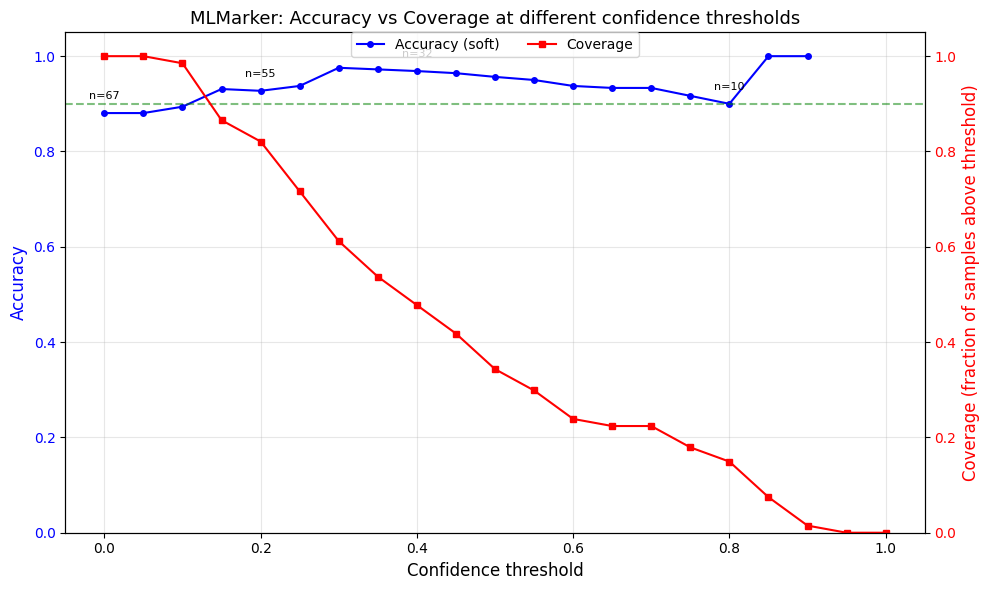

Key thresholds:
  >= 0.1: accuracy=89.4%, coverage=98.5% (66 samples)
  >= 0.2: accuracy=92.7%, coverage=82.1% (55 samples)
  >= 0.3: accuracy=97.6%, coverage=61.2% (41 samples)
  >= 0.4: accuracy=96.9%, coverage=47.8% (32 samples)
  >= 0.5: accuracy=95.7%, coverage=34.3% (23 samples)
  >= 0.6: accuracy=93.8%, coverage=23.9% (16 samples)
  >= 0.7: accuracy=93.3%, coverage=22.4% (15 samples)
  >= 0.8: accuracy=90.0%, coverage=14.9% (10 samples)


In [6]:
# Threshold analysis: at what confidence can we trust predictions?
thresholds = np.round(np.arange(0.0, 1.01, 0.05), 2)
threshold_stats = []

for t in thresholds:
    above = evaluable[evaluable["pred_prob"] >= t]
    if len(above) == 0:
        threshold_stats.append({"threshold": t, "n_samples": 0, "accuracy": np.nan, "coverage": 0})
        continue
    acc = above["soft_match"].mean()
    coverage = len(above) / len(evaluable)
    threshold_stats.append({"threshold": t, "n_samples": len(above), "accuracy": acc, "coverage": coverage})

thresh_df = pd.DataFrame(threshold_stats)

# Plot accuracy vs coverage at different thresholds
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(thresh_df["threshold"], thresh_df["accuracy"], "b-o", markersize=4, label="Accuracy (soft)")
ax1.set_xlabel("Confidence threshold", fontsize=12)
ax1.set_ylabel("Accuracy", color="blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(thresh_df["threshold"], thresh_df["coverage"], "r-s", markersize=4, label="Coverage")
ax2.set_ylabel("Coverage (fraction of samples above threshold)", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")
ax2.set_ylim(0, 1.05)

# Add sample counts
for _, row in thresh_df.iterrows():
    if row["n_samples"] > 0 and abs(row["threshold"] % 0.2) < 0.01:
        ax1.annotate(f'n={int(row["n_samples"])}', (row["threshold"], row["accuracy"]),
                     textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center")

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=10)
ax1.set_title("MLMarker: Accuracy vs Coverage at different confidence thresholds", fontsize=13)
ax1.axhline(y=0.9, color="green", linestyle="--", alpha=0.5, label="90% accuracy")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print key thresholds
print("Key thresholds:")
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    rows = thresh_df[(thresh_df["threshold"] - t).abs() < 0.01]
    if len(rows) == 0:
        continue
    row = rows.iloc[0]
    if row["n_samples"] > 0:
        print(f"  >= {t:.1f}: accuracy={row['accuracy']:.1%}, coverage={row['coverage']:.1%} ({int(row['n_samples'])} samples)")
    else:
        print(f"  >= {t:.1f}: no samples")

## Full-scale evaluation: all labeled NSAF samples (SDRF + run name metadata)

In [7]:
# --- Build combined tissue lookup for ALL NSAF samples ---

# Source 1: SDRF — mapped PXDs (PXD000561, PXD020192) via sample_name_mapping
mapped_pxds = sample_name_mapping["pxd"].unique()
sdrf_mapped = sdrf_metadata[sdrf_metadata["pxd"].isin(mapped_pxds)].copy()
sdrf_mapped["sample_prefix"] = sdrf_mapped["run"].apply(
    lambda r: re.sub(r"[_\-][fF]\d{1,3}$", "", r)
)
sdrf_dedup = sdrf_mapped.drop_duplicates(subset=["pxd", "sample_prefix"])[["pxd", "sample_prefix", "tissue"]]

mapped_with_tissue = sample_name_mapping.merge(
    sdrf_dedup, left_on=["pxd", "descriptive_name"],
    right_on=["pxd", "sample_prefix"], how="left"
)
sdrf_mapped_lookup = mapped_with_tissue[["pxd", "generic_name", "tissue"]].rename(
    columns={"generic_name": "run"}
)
sdrf_mapped_lookup["source"] = "sdrf_mapped"

# Source 2: SDRF — direct match PXDs (run names match between SDRF and NSAF)
sdrf_direct = sdrf_metadata[~sdrf_metadata["pxd"].isin(mapped_pxds)].copy()
sdrf_direct_lookup = sdrf_direct[["pxd", "run", "tissue"]].drop_duplicates(subset=["pxd", "run"])
sdrf_direct_lookup["source"] = "sdrf_direct"

# Source 3: Run name extraction
name_meta = pd.read_csv(r"C:\Users\sander\OneDrive\Bureaublad\Projects\agentic-metadata\notebooks\run_meta_name.tsv", sep="\t")
name_lookup = name_meta[name_meta["tissue"].notna()][["pxd", "run", "tissue"]].copy()
name_lookup["source"] = "run_name"

# Combine: prefer SDRF over run name
all_labels = pd.concat([sdrf_mapped_lookup, sdrf_direct_lookup, name_lookup], ignore_index=True)
all_labels = all_labels.dropna(subset=["tissue"])
all_labels = all_labels.drop_duplicates(subset=["pxd", "run"], keep="first")

print(f"Total tissue labels: {len(all_labels)}")
print(f"  From SDRF (mapped): {(all_labels['source'] == 'sdrf_mapped').sum()}")
print(f"  From SDRF (direct): {(all_labels['source'] == 'sdrf_direct').sum()}")
print(f"  From run name: {(all_labels['source'] == 'run_name').sum()}")

# Join to NSAF data
nsaf_meta = nsaf[["pxd", "run"]].merge(all_labels, on=["pxd", "run"], how="inner")
print(f"\nNSAF samples with tissue label: {len(nsaf_meta)} / {len(nsaf)}")
print(f"Unique tissues: {nsaf_meta['tissue'].nunique()}")
print(f"\nTissue distribution (top 20):")
print(nsaf_meta["tissue"].value_counts().head(20).to_string())

Total tissue labels: 11406
  From SDRF (mapped): 173
  From SDRF (direct): 6505
  From run name: 4728

NSAF samples with tissue label: 4315 / 66761
Unique tissues: 63

Tissue distribution (top 20):
tissue
heart               943
blood plasma        821
liver               388
urine               268
PBMCs               191
brain               189
breast              178
skeletal muscle     168
blood serum         111
kidney              110
saliva              109
sperm               108
stem cells           94
placenta             84
lung                 82
cortex of kidney     81
spleen               64
colon                54
retina               47
urinary bladder      37


In [15]:
# --- Batch predict all labeled NSAF samples (vectorized) ---                                                                                                                      from tqdm.auto import tqdm                                                                                                                                                       
from mlmarker.utils import validate_sample                                                                                                                                       

m_batch = MLMarker()
protein_cols = [c for c in nsaf.columns if c not in ["pxd", "run"]]

labeled_nsaf = nsaf.merge(nsaf_meta[["pxd", "run", "tissue", "source"]], on=["pxd", "run"], how="inner")
print(f"Running MLMarker on {len(labeled_nsaf)} labeled samples (vectorized predict_proba)...")

# Validate ALL samples at once — align columns to model features once
all_samples = labeled_nsaf[protein_cols]
validated_all = validate_sample(m_batch.features, all_samples)

# Predict all at once — single call to predict_proba
probabilities = m_batch.model.predict_proba(validated_all)  # (n_samples, n_classes)
classes = m_batch.model.classes_
print(f"Prediction done! Building results...")

# Build results
all_results = []
for i in tqdm(range(len(labeled_nsaf)), desc="Building results"):
    row = labeled_nsaf.iloc[i]
    probs = probabilities[i]
    ranked = sorted(zip(classes, probs), key=lambda x: x[1], reverse=True)

    top1_tissue, top1_prob = ranked[0]
    all_results.append({
        "pxd": row["pxd"],
        "run": row["run"],
        "true_tissue": row["tissue"],
        "label_source": row["source"],
        "pred_tissue": top1_tissue,
        "pred_prob": round(top1_prob, 4),
        "top5": [(t, round(p, 3)) for t, p in ranked[:5]]
    })

all_results_df = pd.DataFrame(all_results)
print(f"\nDone! {len(all_results_df)} predictions")

c:\Users\sander\miniconda3\envs\agentic-metadata\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\sander\miniconda3\envs\agentic-metadata\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MLMarker on 4315 labeled samples (vectorized predict_proba)...
Prediction done! Building results...


Building results: 100%|██████████| 4315/4315 [00:14<00:00, 298.19it/s]


Done! 4315 predictions


In [16]:
# --- Evaluate with soft matching + threshold analysis ---

# Extend TISSUE_MAP with any new tissues from the full dataset
# Check which true tissues are not yet in the map
unmapped = set(all_results_df["true_tissue"].str.lower().unique()) - set(k.lower() for k in TISSUE_MAP.keys())
if unmapped:
    print(f"Tissues not in TISSUE_MAP (will be excluded): {sorted(unmapped)}")

# Add common additional mappings
TISSUE_MAP.update({
    "blood plasma": None,  # no blood plasma class
    "blood serum": None,   # no blood serum class
    "urine": None,         # no urine class
    "saliva": None,        # no saliva class
    "sperm": None,         # no sperm class
    "stem cells": None,    # no stem cells class
    "PBMCs": ["Monocytes", "B-cells"],  # mixed immune
    "neutrophil": ["Monocytes", "B-cells"],  # immune
    "adipose tissue": ["Adipose tissue"],
    "tonsil": ["Tonsil"],
    "spleen": ["Spleen"],
    "skeletal muscle": ["Skeletal muscle"],
    "cerebrospinal fluid": None,
    "substantia nigra": ["Brain"],
    "cortex of kidney": ["Kidney"],
    "blood": None,
    "skin": None,  # no skin class
    "lymph node": ["Lymph node"],
    "stomach": ["Stomach"],
    "duodenum": ["Duodenum"],
    "small intestine": ["Small intestine"],
    "thyroid gland": ["Thyroid"],
    "bone marrow": ["Bone marrow"],
    "vermiform appendix": ["Appendix"],
    "temporal lobe": ["Brain"],
    "parietal lobe": ["Brain"],
    "occipital lobe": ["Brain"],
    "cerebellum": ["Brain"],
    "epididymis": None,
    "uterine endometrium": ["Endometrium"],
    "salivary gland": ["Salivary gland"],
    "smooth muscle": ["Smooth muscle"],
    "fallopian tube": ["Oviduct"],
    "hypophysis": ["Pituitary gland"],
    "cervix": None,
    "trachea": None,
    "ureter": None,
    "uterus": ["Endometrium"],
    "seminal plasma": None,
    "anus": None,
    "parathyroid gland": None,
})

# Re-check unmapped
unmapped2 = set(all_results_df["true_tissue"].str.lower().unique()) - set(k.lower() for k in TISSUE_MAP.keys())
if unmapped2:
    print(f"Still unmapped: {sorted(unmapped2)}")

# Apply soft matching
all_results_df["soft_match"] = all_results_df.apply(
    lambda r: soft_match(r["true_tissue"], r["pred_tissue"]), axis=1
)
all_results_df["soft_top5"] = all_results_df.apply(
    lambda r: soft_in_top5(r), axis=1
)

evaluable_all = all_results_df[all_results_df["soft_match"].notna()].copy()
evaluable_all["soft_match"] = evaluable_all["soft_match"].astype(bool)
evaluable_all["soft_top5"] = evaluable_all["soft_top5"].astype(bool)

print(f"\nEvaluable samples: {len(evaluable_all)} / {len(all_results_df)}")
print(f"Excluded (no MLMarker equivalent): {all_results_df['soft_match'].isna().sum()}")
print(f"\nSoft top-1 accuracy: {evaluable_all['soft_match'].sum()}/{len(evaluable_all)} = {evaluable_all['soft_match'].mean():.1%}")
print(f"Soft top-5 accuracy: {evaluable_all['soft_top5'].sum()}/{len(evaluable_all)} = {evaluable_all['soft_top5'].mean():.1%}")

# Per-tissue accuracy
print("\nPer-tissue accuracy:")
tissue_acc = evaluable_all.groupby("true_tissue").agg(
    n=("soft_match", "count"),
    correct=("soft_match", "sum"),
    accuracy=("soft_match", "mean"),
    mean_conf=("pred_prob", "mean")
).sort_values("n", ascending=False)
print(tissue_acc.to_string())

Tissues not in TISSUE_MAP (will be excluded): ['adipose tissue', 'anus', 'blood plasma', 'blood serum', 'bone marrow', 'cerebellum', 'cerebrospinal fluid', 'cervix', 'cortex of kidney', 'duodenum', 'fallopian tube', 'lymph node', 'neutrophil', 'occipital lobe', 'parathyroid gland', 'parietal lobe', 'pbmcs', 'saliva', 'salivary gland', 'seminal plasma', 'skeletal muscle', 'skin', 'small intestine', 'sperm', 'spleen', 'stem cells', 'stomach', 'temporal lobe', 'thyroid gland', 'tonsil', 'trachea', 'ureter', 'urine', 'uterine endometrium', 'uterus', 'vermiform appendix']

Evaluable samples: 2390 / 4315
Excluded (no MLMarker equivalent): 1925

Soft top-1 accuracy: 1862/2390 = 77.9%
Soft top-5 accuracy: 2240/2390 = 93.7%

Per-tissue accuracy:
                       n  correct  accuracy  mean_conf
true_tissue                                           
heart                943      927  0.983033   0.295395
liver                388      330  0.850515   0.424364
brain                189      166

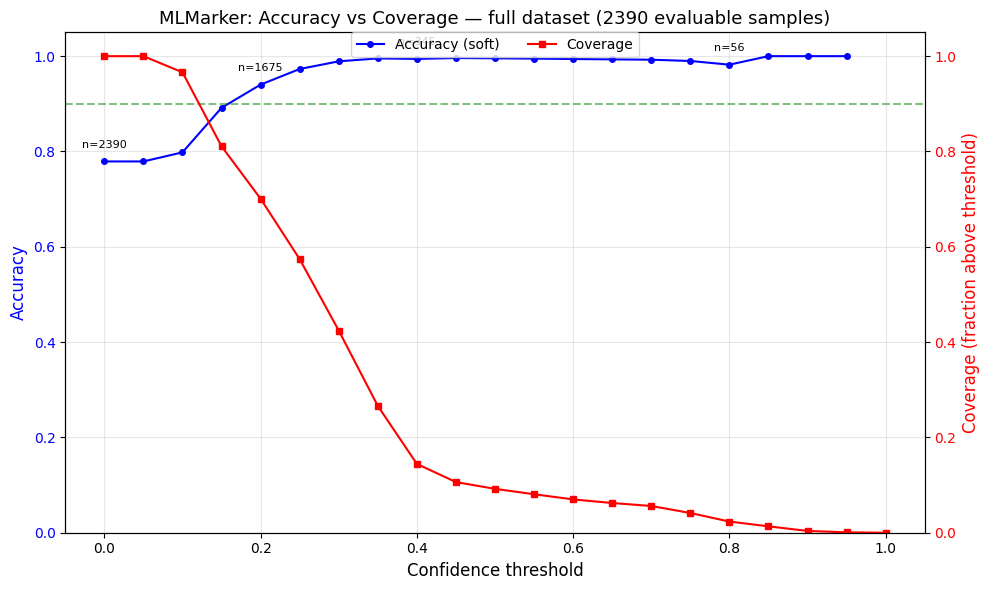

Key thresholds (full dataset):
  >= 0.1: accuracy=79.8%, coverage=96.6% (2309 samples)
  >= 0.2: accuracy=94.0%, coverage=70.1% (1675 samples)
  >= 0.3: accuracy=98.9%, coverage=42.4% (1014 samples)
  >= 0.4: accuracy=99.4%, coverage=14.4% (345 samples)
  >= 0.5: accuracy=99.5%, coverage=9.2% (220 samples)
  >= 0.6: accuracy=99.4%, coverage=7.0% (167 samples)
  >= 0.7: accuracy=99.3%, coverage=5.6% (134 samples)
  >= 0.8: accuracy=98.2%, coverage=2.3% (56 samples)


In [17]:
# --- Threshold analysis on full dataset ---
thresholds = np.round(np.arange(0.0, 1.01, 0.05), 2)
threshold_stats_all = []

for t in thresholds:
    above = evaluable_all[evaluable_all["pred_prob"] >= t]
    if len(above) == 0:
        threshold_stats_all.append({"threshold": t, "n_samples": 0, "accuracy": np.nan, "coverage": 0})
        continue
    acc = above["soft_match"].mean()
    coverage = len(above) / len(evaluable_all)
    threshold_stats_all.append({"threshold": t, "n_samples": len(above), "accuracy": acc, "coverage": coverage})

thresh_df_all = pd.DataFrame(threshold_stats_all)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(thresh_df_all["threshold"], thresh_df_all["accuracy"], "b-o", markersize=4, label="Accuracy (soft)")
ax1.set_xlabel("Confidence threshold", fontsize=12)
ax1.set_ylabel("Accuracy", color="blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(thresh_df_all["threshold"], thresh_df_all["coverage"], "r-s", markersize=4, label="Coverage")
ax2.set_ylabel("Coverage (fraction above threshold)", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")
ax2.set_ylim(0, 1.05)

for _, row in thresh_df_all.iterrows():
    if row["n_samples"] > 0 and abs(row["threshold"] % 0.2) < 0.01:
        ax1.annotate(f'n={int(row["n_samples"])}', (row["threshold"], row["accuracy"]),
                     textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center")

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=10)
ax1.set_title(f"MLMarker: Accuracy vs Coverage — full dataset ({len(evaluable_all)} evaluable samples)", fontsize=13)
ax1.axhline(y=0.9, color="green", linestyle="--", alpha=0.5)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Key thresholds (full dataset):")
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    rows = thresh_df_all[(thresh_df_all["threshold"] - t).abs() < 0.01]
    if len(rows) == 0:
        continue
    row = rows.iloc[0]
    if row["n_samples"] > 0:
        print(f"  >= {t:.1f}: accuracy={row['accuracy']:.1%}, coverage={row['coverage']:.1%} ({int(row['n_samples'])} samples)")
    else:
        print(f"  >= {t:.1f}: no samples")